In [22]:
import numpy as np
import matplotlib.pyplot as plt



In [23]:
# Step 1: Generate synthetic data
def generate_data(n_samples=300, n_clusters=4, cluster_std=0.5, random_state=42):
    np.random.seed(random_state)
    centers = np.random.uniform(-10, 10, (n_clusters, 2))
    data = []
    for center in centers:
        cluster_data = np.random.normal(loc=center, scale=cluster_std, size=(n_samples // n_clusters, 2))
        data.append(cluster_data)
    return np.vstack(data)

In [24]:
# Step 2: Helper function to calculate Euclidean distance
import math

#write your code here
def euclidean_distance(p1, p2):
    squared_differences = [(x - y) ** 2 for x, y in zip(p1, p2)]
    sum_of_squared_differences = sum(squared_differences)
    distance = math.sqrt(sum_of_squared_differences)
    return distance



In [25]:
# Step 3: Find neighbors of a point
def find_neighbors(data, point_idx, eps):
    neighbors = []
    #write your here
    for i, point in enumerate(data):
        if i != point_idx:
            distance = euclidean_distance(data[point_idx], point)
            if distance <= eps:
                neighbors.append(i)

    return neighbors

In [26]:

# Step 4: Expand cluster based on neighbors
def expand_cluster(data, labels, point_idx, cluster_id, eps, min_samples):
    neighbors = find_neighbors(data, point_idx, eps)

    if len(neighbors) < min_samples:
        labels[point_idx] = -1  # Mark as noise
        return False
    else:
        labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]

            if labels[neighbor_idx] == -1:
                labels[neighbor_idx] = cluster_id

            elif labels[neighbor_idx] == 0:
                labels[neighbor_idx] = cluster_id
                new_neighbors = find_neighbors(data, neighbor_idx, eps)
                if len(new_neighbors) >= min_samples:
                    neighbors.extend(new_neighbors)

            i += 1
        return True

In [27]:

# Step 5: DBSCAN algorithm
def dbscan(data, eps, min_samples):
    #write your here
    labels = [0] * len(data)
    cluster = 0

    for point in range(len(data)):
        if labels[point] != 0:
            continue

        if expand_cluster(data, labels, point, cluster + 1, eps, min_samples):
            cluster += 1

    #end your code here

    return labels

In [28]:
# Step 6: Generate data and apply DBSCAN
data = generate_data()
eps = 1.0
min_samples = 5
labels = dbscan(data, eps, min_samples)

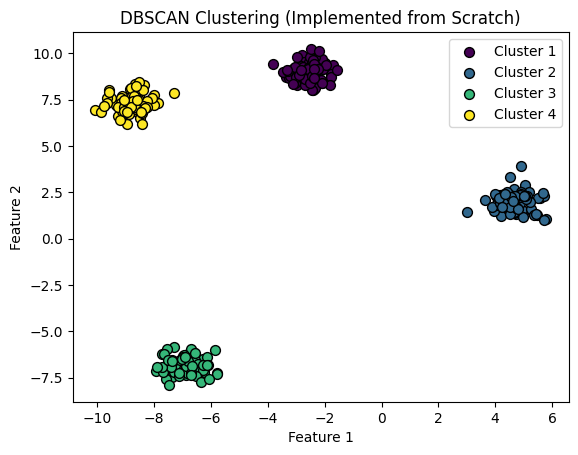

In [29]:

# Step 7: Visualize the clustered data
def visualize_clusters(data, labels):
    unique_labels = set(labels)
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black color for noise
            col = [0, 0, 0, 1]
        class_member_mask = (np.array(labels) == k)
        xy = data[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker='o', s=50, edgecolors='k', label=f"Cluster {k}" if k != -1 else "Noise")

    plt.title("DBSCAN Clustering (Implemented from Scratch)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# Visualize the results
visualize_clusters(data, labels)


In [30]:
# Repeat the same above algorithm with using Manhattan distance

**Dbscan with Manhattan Distance**

In [31]:
def manhattan_distance(p1, p2):
    return sum(abs(x - y) for x, y in zip(p1, p2))

In [32]:
def find_neighbors_manhattan(data, point_idx, eps):
    neighbors = []
    for i, point in enumerate(data):
        if i != point_idx:
            distance = manhattan_distance(data[point_idx], point)
            if distance <= eps:
                neighbors.append(i)
    return neighbors

In [33]:
def expand_cluster_manhattan(data, labels, point_idx, cluster_id, eps, min_samples):
    neighbors = find_neighbors_manhattan(data, point_idx, eps)

    if len(neighbors) < min_samples:
        labels[point_idx] = -1  # Mark as noise
        return False
    else:
        labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]

            if labels[neighbor_idx] == -1:
                labels[neighbor_idx] = cluster_id

            elif labels[neighbor_idx] == 0:
                labels[neighbor_idx] = cluster_id
                new_neighbors = find_neighbors_manhattan(data, neighbor_idx, eps)
                if len(new_neighbors) >= min_samples:
                    neighbors.extend(new_neighbors)

            i += 1
        return True

In [34]:

# Step 5: DBSCAN algorithm
def dbscan_manhattan(data, eps, min_samples):
    #write your here
    labels = [0] * len(data)
    cluster = 0

    for point in range(len(data)):
        if labels[point] != 0:
            continue

        if expand_cluster_manhattan(data, labels, point, cluster + 1, eps, min_samples):
            cluster += 1

    #end your code here

    return labels

In [35]:
# Step 6: Generate data and apply DBSCAN
data = generate_data()
eps = 1.0
min_samples = 5
labels = dbscan_manhattan(data, eps, min_samples)

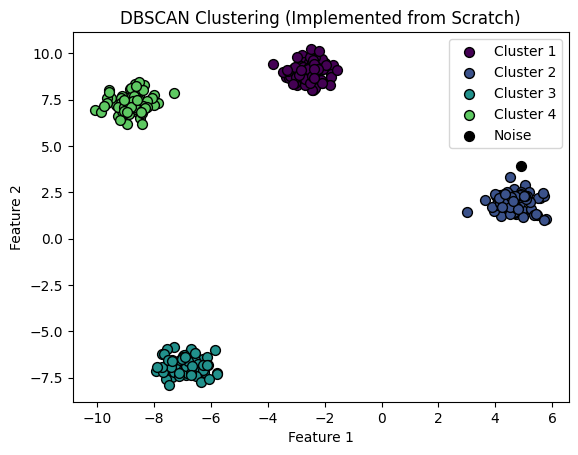

In [36]:

# Step 7: Visualize the clustered data
def visualize_clusters(data, labels):
    unique_labels = set(labels)
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black color for noise
            col = [0, 0, 0, 1]
        class_member_mask = (np.array(labels) == k)
        xy = data[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker='o', s=50, edgecolors='k', label=f"Cluster {k}" if k != -1 else "Noise")

    plt.title("DBSCAN Clustering (Implemented from Scratch)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# Visualize the results
visualize_clusters(data, labels)
